# TC 5033
## Advanced Machine Learning Methods
## Advanced Recurrent Networks and Language Models

### Team 30
- A01796272 - Luis Antonio Ramirez Martinez
- A01796323 - Benjamin Cisneros Barraza
- A01796363 - Arthur Jafed Zizumbo Velasco
- A01796937 - Sandra Luz Cervantes Espinoza

## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import Libraries

We import the following libraries:
- **numpy**: for vector math and cosine similarity computations
- **pickle**: to serialize and deserialize the embeddings dictionary for fast reuse
- **sklearn (PCA, TSNE)**: for dimensionality reduction and 2D visualization
- **matplotlib**: for plotting the embeddings
- **torch / torch.nn.functional**: available for optional tensor operations

In [69]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load GloVe Embeddings

We use the **GloVe 6B 50-dimensional** pre-trained vectors (Jeffrey Pennington et al., 2014).  
Each line in the file follows the format:
```
word val1 val2 ... val50
```
We define the file path and embedding dimension as constants.

In [70]:
PATH = './glove_embeddings/glove.6B.50d.txt'
emb_dim = 50

In [71]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    embeddings_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype=np.float32)
            embeddings_dict[word] = vector
    return embeddings_dict

#### Building the Embeddings Dictionary

`create_emb_dictionary` reads the GloVe file line by line and builds a Python dictionary mapping each word to its embedding as a `numpy` array of `float32`.  
This allows **O(1) lookups** by word, which is critical for efficient similarity and analogy computations.

In [72]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [73]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### Serialization

We serialize the dictionary using `pickle` so it can be reloaded instantly in future sessions without re-parsing the GloVe text file.  
To reload, uncomment the deserialization block and comment out the `create_emb_dictionary` call above.

#### Inspecting the Embeddings

Before visualizing, we print the first few words and their raw vectors to verify the file was loaded correctly and confirm the embedding dimension (50).

In [74]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [75]:
show_n_first_words(PATH, 5)

['the', '0.418', '0.24968', '-0.41242', '0.1217', '0.34527', '-0.044457', '-0.49688', '-0.17862', '-0.00066023', '-0.6566', '0.27843', '-0.14767', '-0.55677', '0.14658', '-0.0095095', '0.011658', '0.10204', '-0.12792', '-0.8443', '-0.12181', '-0.016801', '-0.33279', '-0.1552', '-0.23131', '-0.19181', '-1.8823', '-0.76746', '0.099051', '-0.42125', '-0.19526', '4.0071', '-0.18594', '-0.52287', '-0.31681', '0.00059213', '0.0074449', '0.17778', '-0.15897', '0.012041', '-0.054223', '-0.29871', '-0.15749', '-0.34758', '-0.045637', '-0.44251', '0.18785', '0.0027849', '-0.18411', '-0.11514', '-0.78581'] 50
[',', '0.013441', '0.23682', '-0.16899', '0.40951', '0.63812', '0.47709', '-0.42852', '-0.55641', '-0.364', '-0.23938', '0.13001', '-0.063734', '-0.39575', '-0.48162', '0.23291', '0.090201', '-0.13324', '0.078639', '-0.41634', '-0.15428', '0.10068', '0.48891', '0.31226', '-0.1252', '-0.037512', '-1.5179', '0.12612', '-0.02442', '-0.042961', '-0.28351', '3.5416', '-0.11956', '-0.014533', '-0.

### Dimensionality Reduction and Visualization

Word embeddings live in a 50-dimensional space, which is impossible to visualize directly. We use two complementary techniques to project them into 2D:

- **PCA** (Principal Component Analysis): a linear method that preserves global variance. Fast and deterministic.
- **t-SNE** (t-distributed Stochastic Neighbor Embedding): a non-linear method that preserves local neighborhood structure. Better at revealing clusters.

The function `plot_embeddings` accepts either technique via the `func` parameter.

In [76]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):
    embeddings = np.zeros((len(words2show), emb_dim))
    words2idx = {w:i for i, w in enumerate(words2show)}
    emb_dict = {}

    for word in words2show:
        idx = words2idx[word]
        embeddings[idx] = embeddings_dict[word]

    vectors_2d = func(n_components=2, random_state=43).fit_transform(embeddings)

    plt.figure(figsize=(20, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='red', edgecolors='r')

    for i, word in enumerate(words2show):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

    plt.show()

    return embeddings

In [77]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


#### Word Selection

We select a set of semantically related words across multiple categories (foods, countries, drinks, fruits, academic/work contexts) to observe whether the embedding space places related words close together after dimensionality reduction.

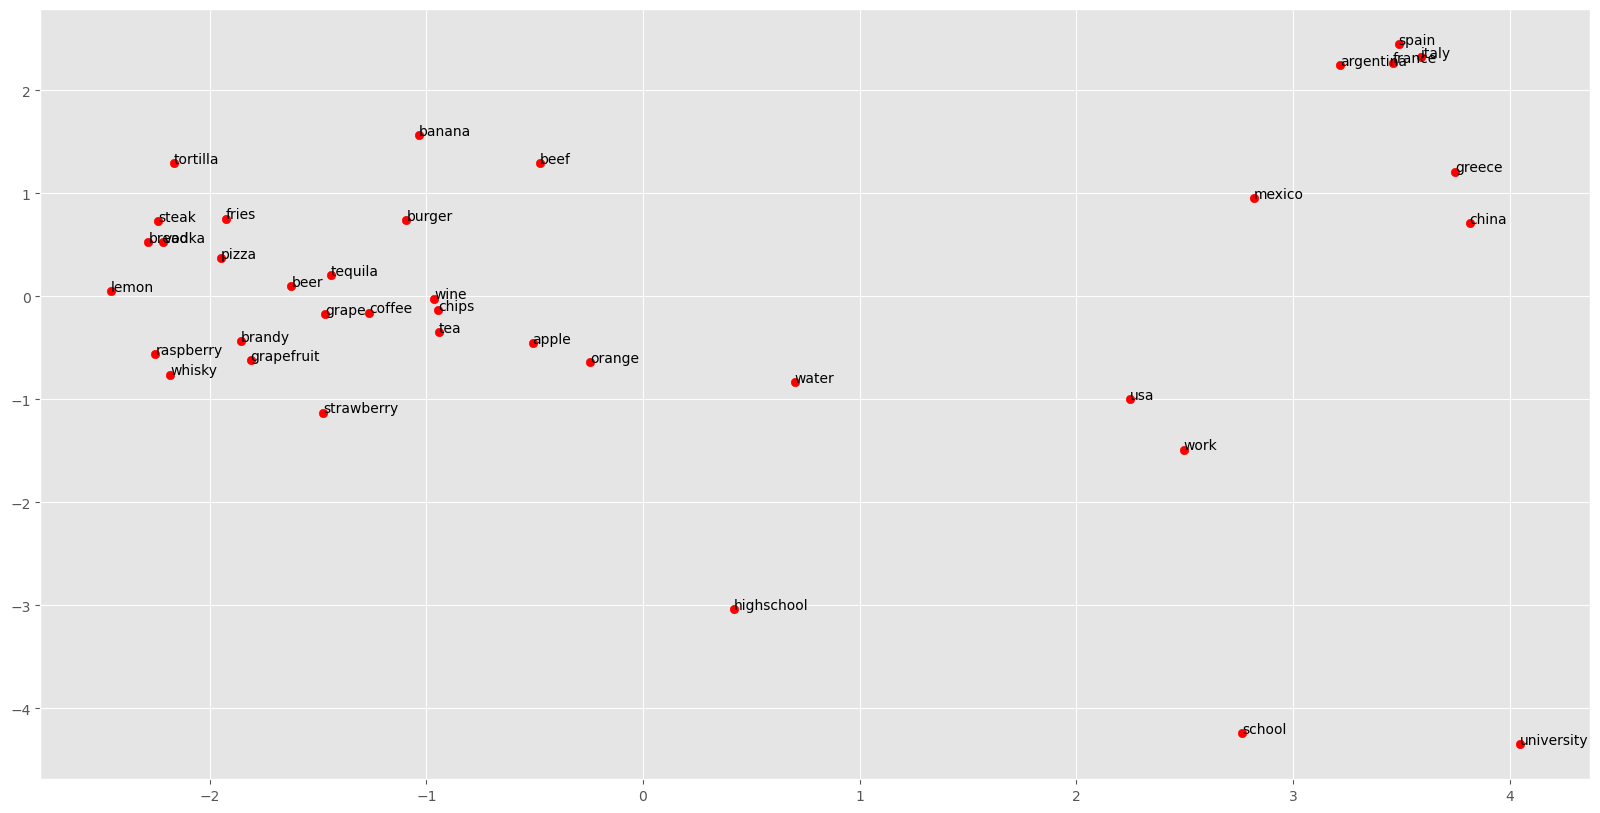

array([[ 0.36973   , -1.17970002, -0.92374998, ..., -0.54113001,
         0.21458   ,  0.81220001],
       [-0.80619001, -1.02450001, -0.28062001, ..., -0.47771001,
        -0.30274999,  0.012332  ],
       [-0.37436   , -0.11959   , -0.87608999, ..., -0.10138   ,
        -0.51134998, -0.18633001],
       ...,
       [ 0.51358998,  0.19695   , -0.51944   , ...,  0.046842  ,
        -0.62897003,  0.35725999],
       [-1.10819995,  1.29159999, -0.78750998, ...,  0.26267999,
        -0.54315001,  0.035944  ],
       [-0.94611001,  0.64415997, -0.30484   , ...,  0.092469  ,
         0.54044998, -0.28299001]], shape=(37, 50))

In [78]:
# 
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

#### t-SNE Visualization

We now apply t-SNE to the same embeddings. Unlike PCA, t-SNE is stochastic and focuses on preserving **local structure**, often revealing tighter, more interpretable clusters.

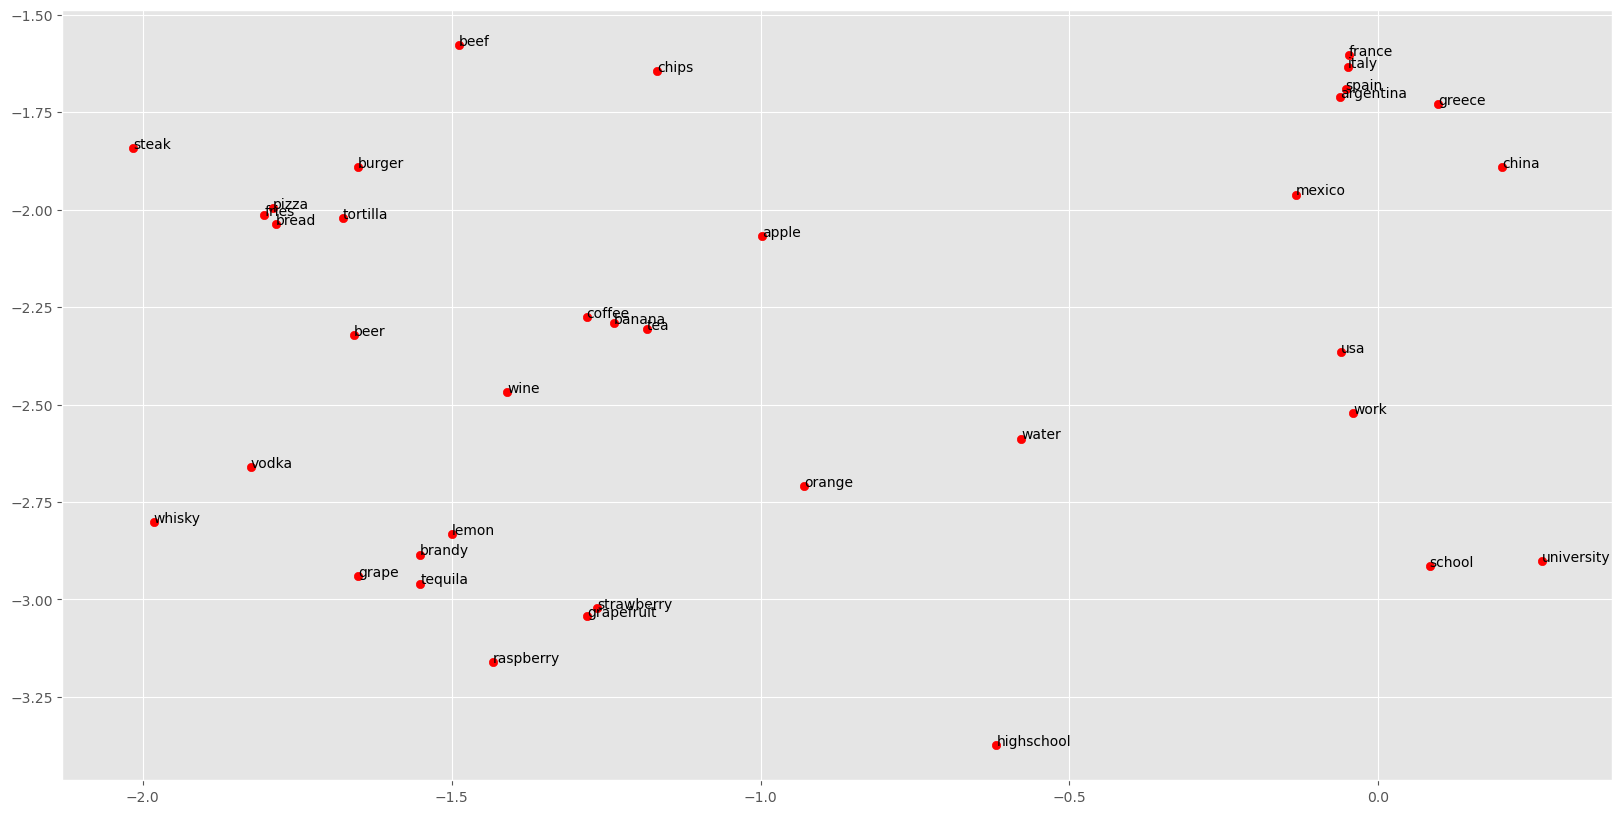

In [79]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Word Analogies

One of the most remarkable properties of word embeddings is that **semantic relationships can be expressed as vector arithmetic**.

For example:
> *"man is to king as woman is to ____"*  
> → `king − man + woman ≈ queen`

The `analogy(word1, word2, word3, embeddings_dict)` function:
1. Computes the target vector: `word2 − word1 + word3`
2. Finds the vocabulary word with the highest **cosine similarity** to that target
3. Excludes the three input words from the result

All computations are done with **numpy only** (no Gensim or similar libraries).

In [80]:
# analogy
# "word1 is to word2 as word3 is to ___"
# e.g. analogy('man', 'king', 'woman') → 'queen'
def analogy(word1, word2, word3, embeddings_dict):
    vec1 = embeddings_dict[word1]
    vec2 = embeddings_dict[word2]
    vec3 = embeddings_dict[word3]

    # target vector: word2 - word1 + word3
    target = vec2 - vec1 + vec3

    # stack all vectors into a matrix for vectorized cosine similarity
    words = list(embeddings_dict.keys())
    vectors = np.array(list(embeddings_dict.values()))  # (vocab, emb_dim)

    # cosine similarity: dot(target, v) / (||target|| * ||v||)
    target_norm = target / np.linalg.norm(target)
    vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    similarities = vectors_norm @ target_norm

    # exclude the three input words
    exclude = {word1, word2, word3}
    best_score, best_word = -np.inf, None
    for idx in np.argsort(similarities)[::-1]:
        if words[idx] not in exclude:
            best_word = words[idx]
            break

    return word1 + ' is to ' + word2 + ' as '+ word3 + ' to ** ' + best_word + ' **'

In [81]:
analogy('man', 'king', 'woman', embeddings_dict)

'man is to king as woman to ** queen **'

In [82]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    target = embeddings_dict[word]

    words = list(embeddings_dict.keys())
    vectors = np.array(list(embeddings_dict.values()))

    target_norm = target / np.linalg.norm(target)
    vectors_norm = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    similarities = vectors_norm @ target_norm

    top_indices = np.argsort(similarities)[::-1]
    results = []
    for idx in top_indices:
        if words[idx] != word:
            results.append((words[idx], similarities[idx]))
        if len(results) == top_n:
            break

    return results

### Word Similarity

`find_most_similar(word, embeddings_dict, top_n)` returns the `top_n` most similar words to a given word using **cosine similarity**:

$$\text{similarity}(u, v) = \frac{u \cdot v}{\|u\| \cdot \|v\|}$$

The implementation:
1. Normalizes all vectors and the target vector
2. Computes all similarities at once via a single matrix-vector product (`@`)
3. Sorts results and returns the top N as a list of `(word, score)` tuples, excluding the input word

In [83]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [84]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> chile
6 ---> puerto
7 ---> rico
8 ---> cuba
9 ---> guatemala
10 ---> panama
